[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Networks Using Blocks: VGG

The previous notebook ended on a complaint.  AlexNet works, but as a *design* it
is a list of choices with no argument behind them: an $11\times11$ kernel, then
$5\times5$, then three $3\times3$; 96 channels, then 256, then 384, 384, 256.
Why 384?  Because it worked.  A list of arbitrary numbers is not something you
can reason about, and it is not something you can make bigger in a principled
way — "make AlexNet deeper" has no obvious meaning.

The network in this notebook answers that:

> Simonyan, K., & Zisserman, A. (2015). Very deep convolutional networks for
> large-scale image recognition. *International Conference on Learning
> Representations*.

**VGG** — named for Oxford's Visual Geometry Group — took second place in the
2014 ImageNet classification challenge with a top-5 error of 7.3%, roughly half
AlexNet's, and won that year's localization task.  But the reason it is still
worth studying is not the score.  It is that VGG replaced the list of layers
with a *repeated block*, and in doing so moved architecture design up a level of
abstraction.  You no longer specify layers; you specify how many blocks, and how
wide each one is.

You have seen this pattern before, though not by this name.  The transformer of
module 04 is a stack of identical blocks, each with the same internal structure,
differing only in their parameters — and the "depth" of a large language model
means the number of those blocks.  That idea starts here.

In [1]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG

import time

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from matplotlib import pyplot as plt

In [2]:
# if you have a GPU we should enable it
# mps is the pytorch device that supports GPU computations on MacOS

device = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Using {device} device')

Using mps device


## Deep and narrow, or shallow and wide?

Before the block, the argument for it.  Simonyan and Zisserman asked a question
that AlexNet's design leaves open: given a fixed budget, is it better to use a
few large convolutions or many small ones?

The key observation is that **stacking convolutions grows the receptive field
additively**.  Notebook 06_02 computed this: a stride-1 convolution with a
$k\times k$ kernel extends the receptive field by $k-1$ in each direction, so a
stack of kernels $k_1, \dots, k_n$ sees a patch of size
$1 + \sum_i (k_i - 1)$.  Two $3\times3$ convolutions therefore cover $5\times5$
pixels, and three cover $7\times7$ — exactly the same reach as the single large
kernel, assembled out of small ones.

Reach being equal, count the cost.  For a layer with $c$ input and $c$ output
channels, a $k \times k$ convolution holds $k^2c^2$ weights, so the comparison is
$49c^2$ against $3 \times 9c^2 = 27c^2$.

In [3]:
def receptive_field(kernel_sizes):
    """Receptive field of a stack of stride-1 convolutions (notebook 06_02)."""
    return 1 + sum(k - 1 for k in kernel_sizes)

def stack_weights(kernel_sizes, channels):
    """Weights in a stack of convolutions, all `channels` in and `channels` out."""
    return sum(k * k * channels * channels for k in kernel_sizes)

channels = 64
print(f'{"stack":26s} {"receptive field":>16s} {"weights":>12s} {"ReLUs":>7s}')
print('-' * 64)
for stack in ([5], [3, 3], [7], [3, 3, 3], [11], [3, 3, 3, 3, 3]):
    rf = receptive_field(stack)
    name = ' + '.join(f'{k}x{k}' for k in stack)
    print(f'{name:26s} {f"{rf}x{rf}":>16s} '
          f'{stack_weights(stack, channels):>12,d} {len(stack):>7d}')

stack                       receptive field      weights   ReLUs
----------------------------------------------------------------
5x5                                     5x5      102,400       1
3x3 + 3x3                               5x5       73,728       2
7x7                                     7x7      200,704       1
3x3 + 3x3 + 3x3                         7x7      110,592       3
11x11                                 11x11      495,616       1
3x3 + 3x3 + 3x3 + 3x3 + 3x3            11x11      184,320       5


Read it in pairs.  Every way of reaching $7\times7$ is on the table, and the
three stacked $3\times3$ convolutions get there with 45% fewer weights than the
single $7\times7$.  Against AlexNet's $11\times11$ first layer the saving is 63%.

And the parameter count is the *smaller* of the two arguments.  A single
$7\times7$ convolution is one linear map followed by one ReLU.  Three stacked
$3\times3$ convolutions are three linear maps with a ReLU between each — the same
receptive field, but a more expressive function of what it sees, because
composing three nonlinear steps is not the same as taking one.  Depth buys
expressiveness that width cannot.

Simonyan and Zisserman tested this carefully — same budget, different
depth-to-width ratios — and found deep-and-narrow the clear winner.  The
conclusion held: $3\times3$ convolutions became the default for the next decade,
GPU vendors wrote special-cased kernels for them, and the field set off toward
networks of a hundred layers and more.  We will get to those in notebook 04.

## The VGG block

With that settled, the block almost writes itself: some number of $3\times3$
convolutions with padding 1, each followed by a ReLU, and then a $2\times2$
max-pool with stride 2.

The padding is what makes this composable.  Padding 1 on a $3\times3$ kernel is
the shape-preserving choice from notebook 06_03, so every convolution in the
block leaves height and width alone, and *all* of the downsampling happens in
one place — the pooling layer at the end.  Resolution therefore halves exactly
once per block, no matter how many convolutions the block contains.

That separation is the whole trick.  In AlexNet, changing the depth changes the
shapes and you have to recompute everything downstream.  Here, depth and
resolution are independent knobs.

In [4]:
def vgg_block(num_convs, out_channels):
    """A VGG block: `num_convs` padded 3x3 convolutions, then halve the resolution."""
    layers = []
    for _ in range(num_convs):
        layers.append(nn.LazyConv2d(out_channels, kernel_size=3, padding=1))
        layers.append(nn.ReLU())
    layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
    return nn.Sequential(*layers)

## The VGG network

A VGG network is a stack of these blocks followed by the same fully connected
head AlexNet used.  Side by side, the difference in how the two are *specified*
is the point of the figure:

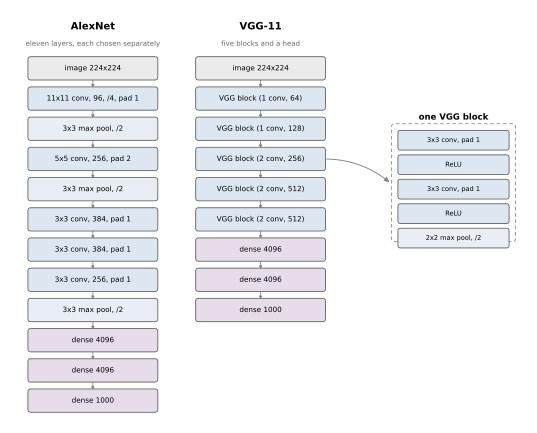

In [5]:
# palette shared by the architecture figures in this module
CONV, POOL, DENSE, DATA = '#dce7f2', '#e8eef3', '#e6dcea', '0.92'

# Geometry is in inches and the axes are set so one data unit is one inch, so the
# boxes stay just wide enough for their labels at a fixed, readable font size.
BOX_W, BOX_H, ROW = 1.78, 0.30, 0.42

def _stack(ax, xc, title, layers, note=None, w=BOX_W):
    """Draw one architecture as a top-to-bottom stack of layer boxes."""
    from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
    ax.text(xc, 0.58, title, ha='center', va='center', fontsize=10,
            fontweight='bold')
    if note:
        ax.text(xc, 0.34, note, ha='center', va='center', fontsize=7,
                color='0.4', linespacing=1.4)
    ys = [-i * ROW for i in range(len(layers))]
    for y, (label, fill) in zip(ys, layers):
        ax.add_patch(FancyBboxPatch((xc - w / 2, y - BOX_H / 2), w, BOX_H,
                                    boxstyle='round,pad=0.012,rounding_size=0.04',
                                    linewidth=0.9, edgecolor='0.4',
                                    facecolor=fill, zorder=3))
        ax.text(xc, y, label, ha='center', va='center', fontsize=7.2, zorder=4)
    for y0, y1 in zip(ys[:-1], ys[1:]):
        ax.add_patch(FancyArrowPatch((xc, y0 - BOX_H / 2), (xc, y1 + BOX_H / 2),
                                     arrowstyle='-|>', mutation_scale=6,
                                     linewidth=0.8, color='0.5', shrinkA=0,
                                     shrinkB=0, zorder=2))
    return ys

def alexnet_to_vgg_figure():
    """AlexNet's layers are designed one at a time; VGG's come in repeated blocks."""
    from matplotlib.patches import FancyBboxPatch
    alexnet = [('image 224x224', DATA),
               ('11x11 conv, 96, /4, pad 1', CONV),
               ('3x3 max pool, /2', POOL),
               ('5x5 conv, 256, pad 2', CONV),
               ('3x3 max pool, /2', POOL),
               ('3x3 conv, 384, pad 1', CONV),
               ('3x3 conv, 384, pad 1', CONV),
               ('3x3 conv, 256, pad 1', CONV),
               ('3x3 max pool, /2', POOL),
               ('dense 4096', DENSE),
               ('dense 4096', DENSE),
               ('dense 1000', DENSE)]
    vgg = [('image 224x224', DATA),
           ('VGG block (1 conv, 64)', CONV),
           ('VGG block (1 conv, 128)', CONV),
           ('VGG block (2 conv, 256)', CONV),
           ('VGG block (2 conv, 512)', CONV),
           ('VGG block (2 conv, 512)', CONV),
           ('dense 4096', DENSE),
           ('dense 4096', DENSE),
           ('dense 1000', DENSE)]

    x_left, x_right = 0.0, BOX_W + 0.55
    x_blk, blk_w = 2 * (BOX_W + 0.55) + 0.35, 1.52
    lo, hi = -BOX_W / 2 - 0.30, x_blk + blk_w / 2 + 0.30
    ys = [-i * ROW for i in range(len(alexnet))]
    bottom, top = min(ys) - 0.35, 0.85

    fig, ax = plt.subplots(figsize=(hi - lo, top - bottom))
    _stack(ax, x_left, 'AlexNet', alexnet,
           note='eleven layers, each chosen separately')
    _stack(ax, x_right, 'VGG-11', vgg, note='five blocks and a head')

    y0 = -1.30
    ax.text(x_blk, y0 + 0.62, 'one VGG block', ha='center', va='center',
            fontsize=8.5, fontweight='bold')
    for k, label in enumerate(['3x3 conv, pad 1', 'ReLU', '3x3 conv, pad 1',
                               'ReLU', '2x2 max pool, /2']):
        y = y0 + 0.30 - k * 0.34
        ax.add_patch(FancyBboxPatch((x_blk - blk_w / 2, y - 0.25 / 2), blk_w, 0.25,
                                    boxstyle='round,pad=0.012,rounding_size=0.035',
                                    linewidth=0.9, edgecolor='0.4',
                                    facecolor=POOL if 'pool' in label else CONV,
                                    zorder=3))
        ax.text(x_blk, y, label, ha='center', va='center', fontsize=6.6, zorder=4)
    ax.add_patch(FancyBboxPatch((x_blk - blk_w / 2 - 0.09, y0 - 1.10),
                                blk_w + 0.18, 1.62,
                                boxstyle='round,pad=0.01,rounding_size=0.04',
                                facecolor='none', edgecolor='0.55', linewidth=0.9,
                                linestyle=(0, (4, 3)), zorder=1))
    ax.annotate('', xy=(x_blk - blk_w / 2 - 0.11, y0 - 0.30),
                xytext=(x_right + BOX_W / 2, -1.26),
                arrowprops=dict(arrowstyle='-|>', color='0.5', linewidth=0.9,
                                connectionstyle='arc3,rad=-0.18'))
    ax.set_xlim(lo, hi)
    ax.set_ylim(bottom, top)
    ax.axis('off')
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

alexnet_to_vgg_figure()

The architecture is now a piece of data rather than a piece of code — a list of
`(num_convs, out_channels)` pairs, one per block.  The original paper's smallest
configuration has five blocks: one convolution each in the first two, two in
each of the last three, with channels starting at 64 and doubling each block
until they cap at 512.  Eight convolutional layers plus three fully connected
ones gives the network its name, **VGG-11**.

This is worth stating plainly: `arch` defines a *family*, not a network.  Adding
convolutions to the tuples gives VGG-16 and VGG-19, which is how the paper's
Table 1 is organized, and which is why practitioners could pick a point on the
accuracy-versus-cost curve without designing anything.  Every architecture since
is described this way.

In [6]:
def make_vgg(arch, num_classes=10, hidden=4096):
    """VGG from a list of (num_convs, out_channels) pairs, one per block."""
    blocks = [vgg_block(num_convs, out_channels)
              for num_convs, out_channels in arch]
    return nn.Sequential(
        *blocks,
        nn.Flatten(),
        nn.LazyLinear(hidden), nn.ReLU(), nn.Dropout(p=0.5),
        nn.LazyLinear(hidden), nn.ReLU(), nn.Dropout(p=0.5),
        nn.LazyLinear(num_classes))

vgg_11 = ((1, 64), (1, 128), (2, 256), (2, 512), (2, 512))

## Following the shapes

Because each block is itself a `nn.Sequential`, iterating over the network gives
us one line per *block* rather than one per layer.  That is the right resolution
to read this network at — the block is the unit of design, and what we want to
check is what each block does to the shape.

In [7]:
def layer_summary(net, X_shape):
    """Print the output shape of every top-level component of the network."""
    X = torch.randn(*X_shape)
    for layer in net:
        X = layer(X)
        print(f'{layer.__class__.__name__:12s} output shape: {tuple(X.shape)}')

model = make_vgg(vgg_11)
layer_summary(model, (1, 1, 224, 224))

Sequential   output shape: (1, 64, 112, 112)
Sequential   output shape: (1, 128, 56, 56)
Sequential   output shape: (1, 256, 28, 28)
Sequential   output shape: (1, 512, 14, 14)
Sequential   output shape: (1, 512, 7, 7)
Flatten      output shape: (1, 25088)
Linear       output shape: (1, 4096)
ReLU         output shape: (1, 4096)
Dropout      output shape: (1, 4096)
Linear       output shape: (1, 4096)
ReLU         output shape: (1, 4096)
Dropout      output shape: (1, 4096)
Linear       output shape: (1, 10)


Five blocks, five halvings: $224 \to 112 \to 56 \to 28 \to 14 \to 7$, with
channels going $64 \to 128 \to 256 \to 512 \to 512$.  Compare that with AlexNet's
$224 \to 54 \to 26 \to 12 \to 5$, which are the numbers you get from an
$11\times11$ stride-4 kernel and three overlapping pools — arithmetic nobody
would choose on purpose.  VGG's shapes are exact powers of two because the design
made them so.

The rule "halve the resolution, double the channels" keeps the amount of data
per block roughly constant: a quarter as many positions, twice as many channels
at each.  It is a useful default, and you will see it again in ResNet.

Now the parameters.

In [8]:
def parameter_summary(net):
    """Print the parameter count of every tensor in the network."""
    total = 0
    for name, param in net.named_parameters():
        print(f'{name:16s} {str(tuple(param.shape)):>20s} {param.numel():>12,d}')
        total += param.numel()
    print('-' * 52)
    print(f'{"total":16s} {"":20s} {total:>12,d}')
    return total

num_params = parameter_summary(model)

conv = sum(p.numel() for m in model.modules()
           if isinstance(m, nn.Conv2d) for p in m.parameters())
dense = sum(p.numel() for m in model.modules()
            if isinstance(m, nn.Linear) for p in m.parameters())
print()
print(f'convolutions {conv:>12,d}  ({conv / num_params:.1%})')
print(f'dense head   {dense:>12,d}  ({dense / num_params:.1%})')

0.0.weight              (64, 1, 3, 3)          576
0.0.bias                        (64,)           64
1.0.weight            (128, 64, 3, 3)       73,728
1.0.bias                       (128,)          128
2.0.weight           (256, 128, 3, 3)      294,912
2.0.bias                       (256,)          256
2.2.weight           (256, 256, 3, 3)      589,824
2.2.bias                       (256,)          256
3.0.weight           (512, 256, 3, 3)    1,179,648
3.0.bias                       (512,)          512
3.2.weight           (512, 512, 3, 3)    2,359,296
3.2.bias                       (512,)          512
4.0.weight           (512, 512, 3, 3)    2,359,296
4.0.bias                       (512,)          512
4.2.weight           (512, 512, 3, 3)    2,359,296
4.2.bias                       (512,)          512
6.weight                (4096, 25088)  102,760,448
6.bias                        (4096,)        4,096
9.weight                 (4096, 4096)   16,777,216
9.bias                        (

129 million parameters, against AlexNet's 47 million.  Note the parameter names
in the listing: `0.0.weight`, `2.2.weight` and so on — two indices, because the
blocks are nested `Sequential`s and PyTorch composes the names positionally.
The first index selects the block, the second the layer inside it.

But look at where the parameters are.  The convolutional body — eight layers,
all the perceptual work — holds about 9 million.  The three dense layers hold
120 million, 93% of the network, and a single one of them, the $25088 \times 4096$
matrix right after the flatten, holds 103 million on its own.

We diagnosed this in AlexNet and it has become *worse*.  All of VGG's careful
economy is in the convolutional body, and it is swamped by a fully connected
head that was inherited from AlexNet without much thought.  Two notebooks from
now, ResNet will delete that head entirely and replace it with global average
pooling, at which point a network with more layers than VGG has an order of
magnitude fewer parameters.

## Training

VGG-11 at full width is a serious network — 129 million parameters and several
times AlexNet's arithmetic per image.  Training it on Fashion-MNIST would take
hours and would be pointless besides, since the dataset does not have 129 million
parameters' worth of information in it.

So we do what the paper's own Table 1 invites us to do and pick a smaller member
of the family.  Dividing every channel count by four leaves the architecture —
the depth, the block structure, the $3\times3$ kernels, the halvings — completely
intact, and changes only how wide it is.  This is the payoff of a parameterized
family: "smaller" is a well-defined operation.

The head has to be narrowed along with the body, and it is worth seeing why.
Quartering the channels divides the *convolutional* parameters by sixteen, but
the $4096$-unit dense layers barely notice: their input shrinks from 25088 to
6272, and the second one not at all.  Narrowing only the body would leave a
network of 43 million parameters, 99% of them still in the head.  So we quarter
`hidden` too.  The dominance of the fully connected layers is not a detail you
can work around by making the convolutions smaller — it has to be attacked
directly, which is what notebook 04 does.

In [9]:
# same architecture, a quarter of the width -- in the head as well as the body
vgg_small = tuple((num_convs, channels // 4) for num_convs, channels in vgg_11)
hidden_small = 4096 // 4
print('full  :', vgg_11, 'hidden 4096')
print('narrow:', vgg_small, f'hidden {hidden_small}')

small = make_vgg(vgg_small, hidden=hidden_small)
small(torch.randn(1, 1, 224, 224))     # materialize the Lazy layers
small_params = sum(p.numel() for p in small.parameters())
print(f'\nparameters: {small_params:,d} ({small_params / num_params:.1%} of VGG-11)')

full  : ((1, 64), (1, 128), (2, 256), (2, 512), (2, 512)) hidden 4096
narrow: ((1, 16), (1, 32), (2, 64), (2, 128), (2, 128)) hidden 1024

parameters: 8,060,234 (6.3% of VGG-11)


In [10]:
batch_size = 128
data_dir = '../data'

# As in the AlexNet notebook: set train_subset to an integer for a smaller,
# class-balanced training set, or None to use all 60,000 images.
train_subset = None

transform = transforms.Compose([transforms.Resize((224, 224)),
                                transforms.ToTensor()])

train_set = datasets.FashionMNIST(data_dir, train=True, download=True,
                                  transform=transform)
val_set = datasets.FashionMNIST(data_dir, train=False, download=True,
                                transform=transform)
labels = train_set.classes

if train_subset is not None:
    per_class = train_subset // len(labels)
    indices = torch.cat([torch.where(train_set.targets == c)[0][:per_class]
                         for c in range(len(labels))])
    train_set = torch.utils.data.Subset(train_set, indices.tolist())

train_iter = DataLoader(train_set, batch_size, shuffle=True)
val_iter = DataLoader(val_set, batch_size)

print(f'{len(train_set)} training and {len(val_set)} validation images, '
      f'shape {tuple(val_set[0][0].shape)}')

60000 training and 10000 validation images, shape (1, 224, 224)


In [11]:
def init_cnn(module):
    """Xavier-initialize the weights of convolutional and linear layers."""
    if type(module) in (nn.Linear, nn.Conv2d):
        nn.init.xavier_uniform_(module.weight)
        nn.init.zeros_(module.bias)

def accuracy(Y_hat, Y):
    """Fraction of correct predictions."""
    return (Y_hat.argmax(dim=1) == Y).float().mean()

model = make_vgg(vgg_small, hidden=hidden_small).to(device)
# the Lazy layers need to see data once before their parameters exist
model(next(iter(train_iter))[0].to(device))
model.apply(init_cnn)

optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
loss_fn = nn.CrossEntropyLoss()

In [12]:
epochs = 10
loss_train, loss_valid, accuracy_valid = [], [], []

for epoch in range(epochs):
    start = time.time()
    model.train()
    loss_values = []
    for batch_X, batch_y in train_iter:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        preds = model(batch_X)
        loss = loss_fn(preds, batch_y)
        loss_values.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_train.append(np.mean(loss_values))

    model.eval()
    loss_values, accuracy_values = [], []
    for batch_X, batch_y in val_iter:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        with torch.no_grad():
            preds = model(batch_X)
            loss_values.append(loss_fn(preds, batch_y).item())
            accuracy_values.append(accuracy(preds, batch_y).item())
    loss_valid.append(np.mean(loss_values))
    accuracy_valid.append(np.mean(accuracy_values))

    print(f'epoch {epoch + 1:2d}  train loss {loss_train[-1]:.3f}  '
          f'val loss {loss_valid[-1]:.3f}  '
          f'val accuracy {accuracy_valid[-1]:.3f}  '
          f'({time.time() - start:.1f} s)')

epoch  1  train loss 0.898  val loss 0.462  val accuracy 0.832  (172.9 s)
epoch  2  train loss 0.436  val loss 0.358  val accuracy 0.870  (169.9 s)
epoch  3  train loss 0.354  val loss 0.307  val accuracy 0.889  (177.7 s)
epoch  4  train loss 0.311  val loss 0.302  val accuracy 0.892  (204.7 s)
epoch  5  train loss 0.282  val loss 0.266  val accuracy 0.904  (234.5 s)
epoch  6  train loss 0.260  val loss 0.276  val accuracy 0.898  (209.7 s)
epoch  7  train loss 0.243  val loss 0.237  val accuracy 0.913  (206.9 s)
epoch  8  train loss 0.227  val loss 0.241  val accuracy 0.912  (211.4 s)
epoch  9  train loss 0.213  val loss 0.225  val accuracy 0.917  (217.2 s)
epoch 10  train loss 0.204  val loss 0.226  val accuracy 0.917  (214.5 s)


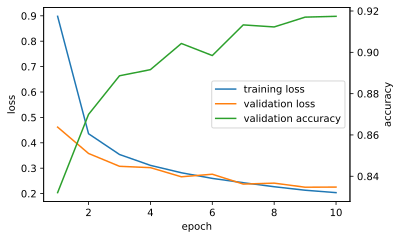

In [13]:
# loss and accuracy live on different scales, so give each its own y-axis
fig, ax1 = plt.subplots(figsize=(5.5, 3.5))
epochs_range = range(1, len(loss_train) + 1)
ax1.plot(epochs_range, loss_train, color='C0', label='training loss')
ax1.plot(epochs_range, loss_valid, color='C1', label='validation loss')
ax1.set_xlabel('epoch')
ax1.set_ylabel('loss')
ax2 = ax1.twinx()
ax2.plot(epochs_range, accuracy_valid, color='C2',
         label='validation accuracy')
ax2.set_ylabel('accuracy')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right');

Compare the final accuracy with the AlexNet notebook's.  A quarter-width VGG
holds roughly a sixth of AlexNet's parameters, and is deeper; if the
deep-and-narrow claim has any force at this scale, this is where you would see
it.

Be careful about how much weight to put on the comparison, though.  Fashion-MNIST is a small,
low-resolution, ten-class problem, and any conclusion drawn here about depth is
at best suggestive — the paper's version of this experiment ran on 1.2 million
images at full resolution, which is what makes it evidence.  What our run does
show honestly is that the block structure works, that the shapes come out where
the design says they will, and that narrowing a network is a one-line change when
the architecture is a parameter.

### Saving the trained model

The same pattern as before.  Note that the checkpoint is much smaller than
AlexNet's 187 MB, because we trained the narrow member of the family.

In [ ]:
model_path = 'vgg_small_fashion_mnist.pt'
torch.save(model.state_dict(), model_path)

reloaded = make_vgg(vgg_small, hidden=hidden_small).to(device)
# materialize the Lazy layers' parameters before loading into them
reloaded(torch.zeros(1, 1, 224, 224, device=device))
reloaded.load_state_dict(torch.load(model_path, map_location=device))
reloaded.eval();

import os
print(f'saved {model_path} ({os.path.getsize(model_path) / 1e6:.1f} MB)')

## Summary

* **VGG replaced individually designed layers with a repeated block**, and an
  architecture with a list of `(num_convs, out_channels)` pairs.  This is the
  organizing idea of every architecture since, convolutional or not — the
  transformer stack of module 04 is the same move.
* **Small kernels, stacked, beat large ones.**  Three $3\times3$ convolutions
  reach as far as one $7\times7$, with 45% fewer weights and three
  nonlinearities instead of one.  Depth buys expressiveness that width does not,
  and $3\times3$ has been the default kernel ever since.
* **Padding inside the block, pooling at the end**, so depth and resolution are
  independent knobs.  Shapes come out as clean powers of two rather than as the
  residue of arbitrary kernel arithmetic.
* **`arch` defines a family.**  VGG-11, VGG-16 and VGG-19 differ only in that
  list, and narrowing the network for a laptop is a one-line change.
* **The fully connected head is now 93% of the parameters** — 129 million in
  total, with 103 million in a single matrix.  VGG made the convolutional body
  efficient and left the head untouched, and that imbalance is what ResNet
  attacks in notebook 04.

## Exercises

1. **Build VGG-16.**  Table 1 of the paper gives the configurations; VGG-16 uses
   two convolutions in the first two blocks and three in each of the last three.
   Write the `arch` tuple and check the parameter count against the paper's
   138 million.  How much of the increase is in the convolutional body?
2. **Stop upsampling.**  Feeding $28\times28$ images at $224\times224$ is as
   wasteful here as it was for AlexNet.  Cut the input to $56\times56$ and remove
   blocks until the shapes work out.  What is the largest number of blocks the
   input size allows, and why is that limit $\log_2$ of the input width?
3. **Test the deep-and-narrow claim yourself.**  Build two networks with roughly
   equal parameter counts — one with `((1, 64), (1, 128), (1, 256), (1, 512))`
   and one with more blocks and fewer channels each.  Train both.  Does depth
   win at this scale, and is your experiment strong enough to support the answer?
4. **Kill the head.**  Replace `nn.Flatten()` and the first `nn.LazyLinear(4096)`
   with `nn.AdaptiveAvgPool2d(1)` followed by `nn.Flatten()`.  Count the
   parameters before and after, and compare accuracy.  You have just built, by
   hand, the change ResNet makes.
5. **Where does the time go?**  Adapt `cost_summary` from the AlexNet notebook to
   VGG-11 and compute the multiply-accumulates per block.  Which block is the
   most expensive, and why is it not the one with the most parameters?
6. Trace the receptive field of a unit in the output of the fifth block back to
   the input image, using `receptive_field` and accounting for the four pooling
   layers before it.  Does a single unit at that depth see the whole image?
7. The first block of VGG-11 has one convolution; the paper's VGG-13 has two.
   Predict the effect on accuracy and on cost before training either, then check.